# Q4 — Salary and Satisfaction Gaps by Gender and Education

**Question:** How do salary and satisfaction differ across gender and education levels?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Median salary: gender x education

In [2]:
salary_gap = pd.pivot_table(df, values="salary_midpoint", index="gender",
                             columns="education", aggfunc="median")
salary_gap

education,Associates,Bachelors,High School,Masters,None,PhD
gender,,,,,,
Female,"95,500.00","53,000.00","53,000.00","53,000.00","53,000.00","57,750.00"
Male,"20,000.00","20,000.00","20,000.00","53,000.00","53,000.00","187,500.00"


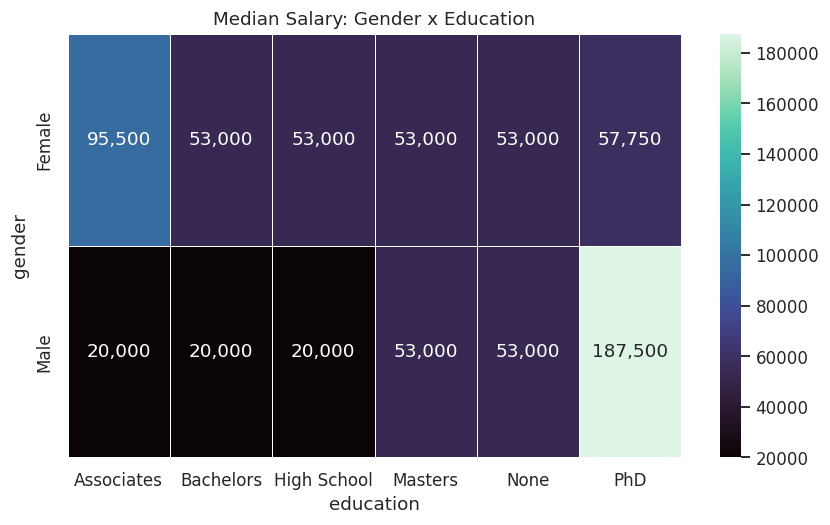

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(salary_gap, annot=True, fmt=",.0f", cmap="mako", linewidths=0.5, ax=ax)
ax.set_title("Median Salary: Gender x Education")
fig.savefig(OUT / "q4_salary_gender_education_heatmap.png", bbox_inches="tight")
plt.show()

### Mean composite satisfaction: gender x education

In [4]:
satisfaction_gap = pd.pivot_table(df, values="satisfaction_composite", index="gender",
                                   columns="education", aggfunc="mean")
satisfaction_gap

education,Associates,Bachelors,High School,Masters,None,PhD
gender,,,,,,
Female,6.00,5.08,4.50,5.10,5.33,7.42
Male,5.14,5.33,5.09,5.36,5.01,6.45


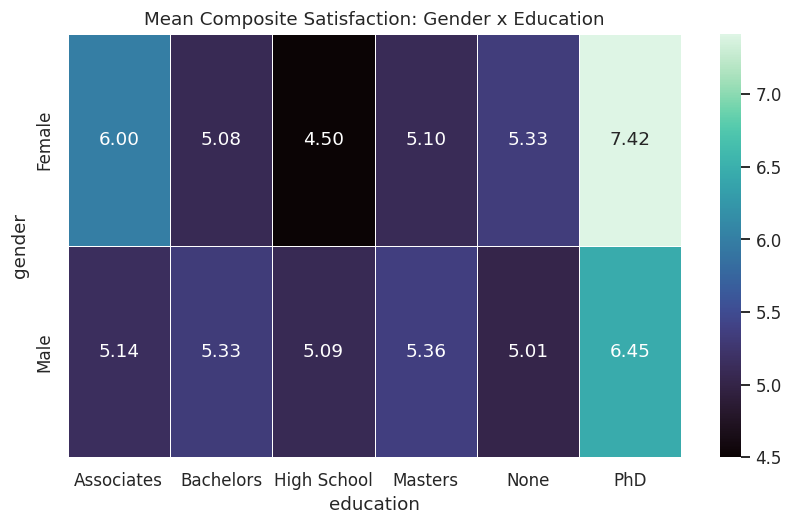

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(satisfaction_gap, annot=True, fmt=".2f", cmap="mako", linewidths=0.5, ax=ax)
ax.set_title("Mean Composite Satisfaction: Gender x Education")
fig.savefig(OUT / "q4_satisfaction_gender_education_heatmap.png", bbox_inches="tight")
plt.show()

**Takeaway:** Gaps are uneven and non-monotonic (e.g. male PhDs show a much higher median salary than female PhDs, but the reverse holds for satisfaction). Some cells have small sample sizes — worth flagging as a caveat rather than a clean trend.

# Q4b — Gender & Education Deep Dive: Full Satisfaction Breakdowns

**Question:** Beyond the gender x education pivot: how does each satisfaction dimension differ by gender alone, and by education alone?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

DIMS = ["satisfaction_salary", "satisfaction_worklife", "satisfaction_coworkers",
        "satisfaction_management", "satisfaction_mobility", "satisfaction_learning"]

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Gender counts

In [2]:
df["gender"].value_counts()

gender
Male      468
Female    162
Name: count, dtype: int64

### Satisfaction by gender (all 6 dimensions + composite)

In [3]:
gender_rows = []
for dim in DIMS + ["satisfaction_composite"]:
    gender_rows.append({
        "dimension": dim.replace("satisfaction_", ""),
        "male": df.loc[df["gender"] == "Male", dim].mean(),
        "female": df.loc[df["gender"] == "Female", dim].mean(),
    })
gender_satisfaction = pd.DataFrame(gender_rows).set_index("dimension")
gender_satisfaction["gap"] = gender_satisfaction["male"] - gender_satisfaction["female"]
gender_satisfaction

,male,female,gap
dimension,,,
salary,4.27,4.28,-0.02
worklife,5.77,5.66,0.11
coworkers,5.86,5.85,0.01
management,5.38,5.17,0.22
mobility,4.80,4.65,0.15
learning,5.72,5.28,0.44
composite,5.29,5.12,0.17


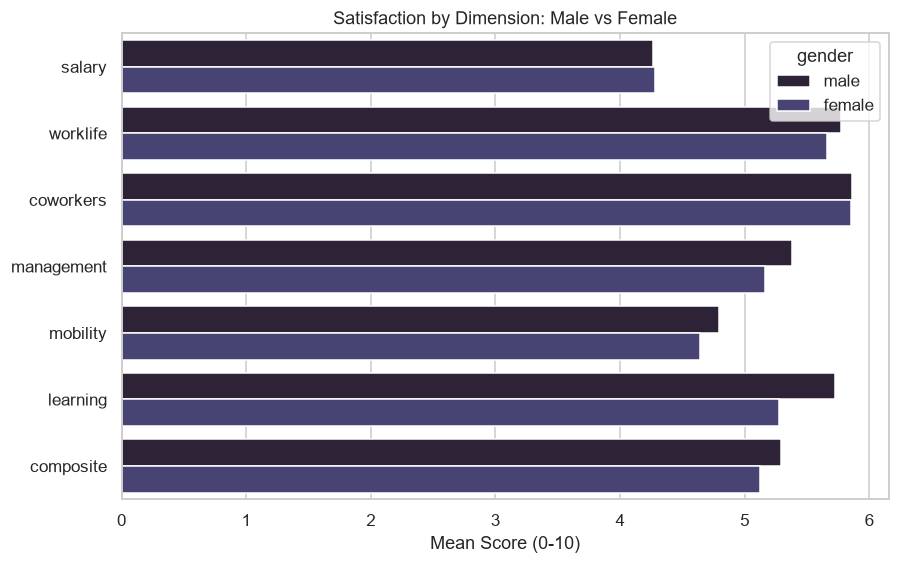

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
data = gender_satisfaction[["male", "female"]].reset_index().melt(
    id_vars="dimension", var_name="gender", value_name="score")
sns.barplot(data=data, y="dimension", x="score", hue="gender", ax=ax)
ax.set_title("Satisfaction by Dimension: Male vs Female")
ax.set_xlabel("Mean Score (0-10)")
ax.set_ylabel("")
fig.savefig(OUT / "q4b_satisfaction_by_gender_all_dims.png", bbox_inches="tight")
plt.show()

### Salary and overall satisfaction by education level

In [5]:
education_summary = df.groupby("education").agg(
    respondents=("respondent_id", "count"),
    avg_salary=("salary_midpoint", "mean"),
    avg_satisfaction=("satisfaction_composite", "mean"),
).sort_values("avg_salary", ascending=False)
education_summary

,respondents,avg_salary,avg_satisfaction
education,,,
PhD,5,"129,700.00",6.83
Masters,192,"61,190.10",5.26
None,52,"55,865.38",5.07
Bachelors,329,"49,554.71",5.27
High School,36,"47,652.78",4.97
Associates,16,"43,000.00",5.25


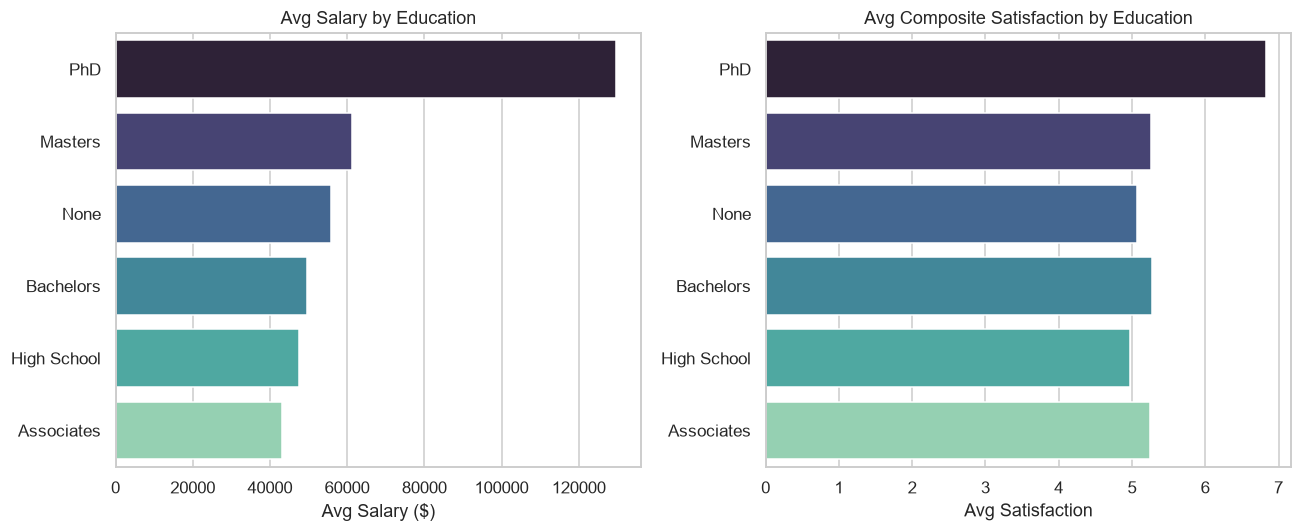

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
data = education_summary.reset_index()
sns.barplot(data=data, y="education", x="avg_salary", ax=axes[0], hue="education", legend=False)
axes[0].set_title("Avg Salary by Education")
axes[0].set_xlabel("Avg Salary ($)")
axes[0].set_ylabel("")
sns.barplot(data=data, y="education", x="avg_satisfaction", ax=axes[1], hue="education", legend=False)
axes[1].set_title("Avg Composite Satisfaction by Education")
axes[1].set_xlabel("Avg Satisfaction")
axes[1].set_ylabel("")
fig.tight_layout()
fig.savefig(OUT / "q4b_salary_satisfaction_by_education.png", bbox_inches="tight")
plt.show()

### Satisfaction by education (all 6 dimensions + composite)

In [7]:
edu_rows = []
for edu in sorted(df["education"].unique()):
    row = {"education": edu, "respondents": (df["education"] == edu).sum()}
    for dim in DIMS + ["satisfaction_composite"]:
        row[dim.replace("satisfaction_", "avg_")] = df.loc[df["education"] == edu, dim].mean()
    edu_rows.append(row)
education_dim_profile = pd.DataFrame(edu_rows).set_index("education").sort_values(
    "avg_composite", ascending=False)
education_dim_profile

,respondents,avg_salary,avg_worklife,avg_coworkers,avg_management,avg_mobility,avg_learning,avg_composite
education,,,,,,,,
PhD,5,6.40,7.20,7.20,6.60,6.80,6.80,6.83
Bachelors,329,4.10,5.75,5.99,5.44,4.80,5.70,5.27
Masters,192,4.54,5.78,5.79,5.29,4.68,5.52,5.26
Associates,16,4.13,6.07,5.67,5.20,4.87,5.93,5.25
None,52,4.37,5.63,5.80,4.98,4.41,5.02,5.07
High School,36,3.97,5.29,5.00,4.86,4.97,5.78,4.97


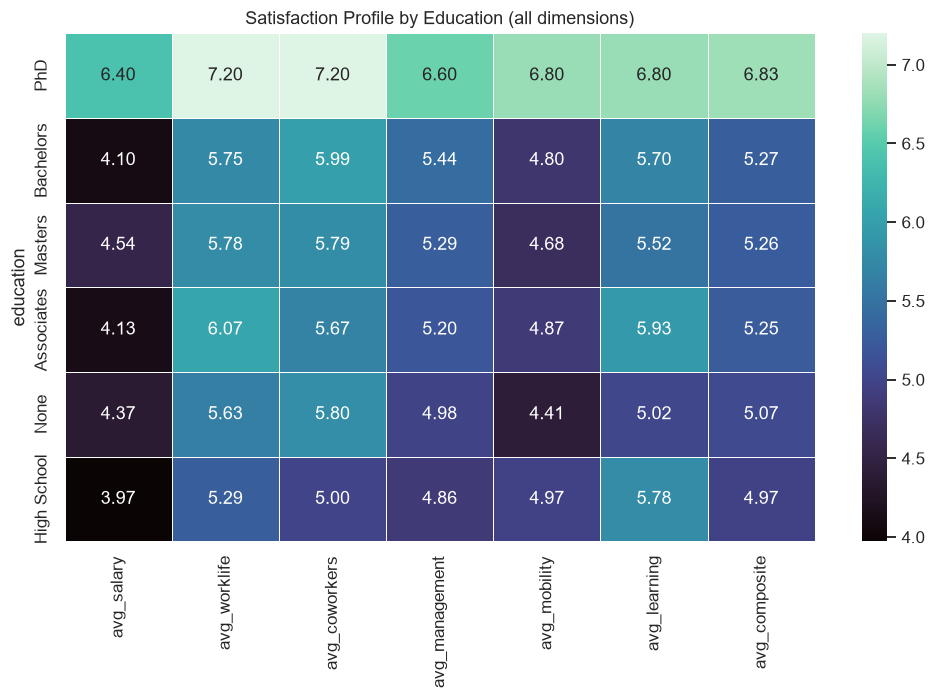

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
heat_cols = [c for c in education_dim_profile.columns if c.startswith("avg_")]
sns.heatmap(education_dim_profile[heat_cols], annot=True, fmt=".2f", cmap="mako",
            linewidths=0.5, ax=ax)
ax.set_title("Satisfaction Profile by Education (all dimensions)")
fig.savefig(OUT / "q4b_education_satisfaction_profile_heatmap.png", bbox_inches="tight")
plt.show()

**Takeaway:** Gender gaps are fairly small and mixed across dimensions — no single dimension shows a large, consistent gap either way. Education shows a clearer pattern: composite satisfaction doesn't rise in a straight line with more education, worth flagging alongside the salary-by-education numbers above.